# Curso 2, Semana 1 — Inicialización de parámetros
# *Dev:* Kevin Vargas Flores

**Continuidad con la práctica anterior.** Conservaremos la convención de ejemplos por columnas, el diccionario de parámetros `W1`, `b1`, ..., las cachés por capa y el ciclo `L_model_forward → costo → L_model_backward → update_parameters_deep`. La única modificación central será **cómo se inicializan los pesos**.

**Objetivos**

1. Comprobar por qué los pesos no deben inicializarse todos en cero.
2. Observar qué ocurre cuando los pesos iniciales son demasiado grandes o pequeños.
3. Implementar **Xavier para `tanh`** y **He para ReLU**.
4. Relacionar la escala de los pesos con las activaciones y los gradientes.

> Una inicialización adecuada no garantiza la convergencia, pero ayuda a que las activaciones y los gradientes comiencen en una escala útil.


## Instrucciones para estudiantes

Completa únicamente las secciones marcadas con `TODO`. Las funciones generales de propagación, costo y actualización se conservan porque ya fueron desarrolladas en la práctica del Curso 1.

**Entregables:** código completo, tabla de diagnósticos, curva de costo, fronteras de decisión y respuestas breves a las preguntas finales.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

SEED = 42
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})

## 1. Datos y convención de dimensiones

Usaremos `make_moons` y una red con arquitectura:

Usaremos la misma arquitectura profunda presentada al final de la práctica anterior:

$$[n^{[0]},n^{[1]},n^{[2]},n^{[3]},n^{[4]}]=[2,16,8,4,1].$$

Cada ejemplo ocupa una columna:

$$X\in\mathbb{R}^{2\times m},\qquad W^{[l]}\in\mathbb{R}^{n^{[l]}\times n^{[l-1]}}.$$

La normalización se calcula **solo con entrenamiento** para evitar fuga de información.


X_train: (2, 450) Y_train: (1, 450)


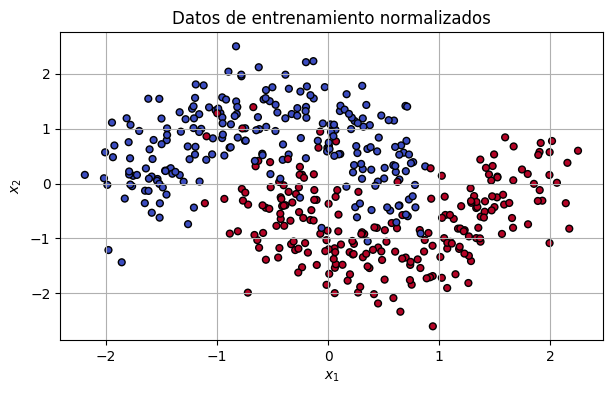

In [ ]:
X_raw, y_raw = make_moons(n_samples=600, noise=0.25, random_state=SEED)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.25, stratify=y_raw, random_state=SEED
)

mu = X_train_raw.mean(axis=0, keepdims=True)
sigma = X_train_raw.std(axis=0, keepdims=True)
X_train = ((X_train_raw - mu) / sigma).T
X_test = ((X_test_raw - mu) / sigma).T
Y_train = y_train_raw.reshape(1, -1)
Y_test = y_test_raw.reshape(1, -1)

assert X_train.shape[0] == 2 and Y_train.shape[0] == 1
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)

plt.scatter(X_train[0], X_train[1], c=Y_train.ravel(), cmap="coolwarm", edgecolor="k", s=24)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.title("Datos de entrenamiento normalizados")
plt.show()


## 2. ¿Qué escala deben tener los pesos?

Para una neurona:

$$Z=\sum_{j=1}^{n_{in}}W_jA_j.$$

Si las entradas están centradas, tienen varianza cercana a uno y son aproximadamente independientes:

$$\operatorname{Var}(Z)\approx n_{in}\operatorname{Var}(W).$$

Por eso la desviación estándar de los pesos disminuye cuando aumenta el número de entradas.

| Activación oculta | Inicialización | Distribución de cada peso |
|---|---|---|
| `tanh` | Xavier | $W_{ij}\sim\mathcal{N}(0,1/n_{in})$ |
| ReLU | He | $W_{ij}\sim\mathcal{N}(0,2/n_{in})$ |

En NumPy, `standard_normal((filas, columnas))` genera primero valores $\mathcal{N}(0,1)$; después se multiplican por la desviación estándar requerida.


### De la varianza de $Z$ a Xavier y He

Si $Z=\sum_{j=1}^{n_{in}}W_jA_j$ y suponemos entradas y pesos independientes, centrados en cero, entonces:

$$\operatorname{Var}(Z)=\sum_{j=1}^{n_{in}}\operatorname{Var}(W_jA_j)
\approx n_{in}\operatorname{Var}(W)\operatorname{Var}(A).$$

Si $\operatorname{Var}(A)\approx1$, pesos con varianza uno harían que la varianza de $Z$ creciera aproximadamente como $n_{in}$ en cada capa. Para evitarlo:

- **Xavier:** elige $\operatorname{Var}(W)=1/n_{in}$. Es apropiada para activaciones simétricas como `tanh`.
- **He:** elige $\operatorname{Var}(W)=2/n_{in}$. El factor 2 compensa que ReLU convierte aproximadamente la mitad de sus entradas en cero.

El segundo parámetro de $\mathcal N(0,\sigma^2)$ es la **varianza**. Por eso, en código se multiplica por la desviación estándar:

```python
W_xavier = rng.standard_normal(shape) * np.sqrt(1 / n_in)
W_he      = rng.standard_normal(shape) * np.sqrt(2 / n_in)
```


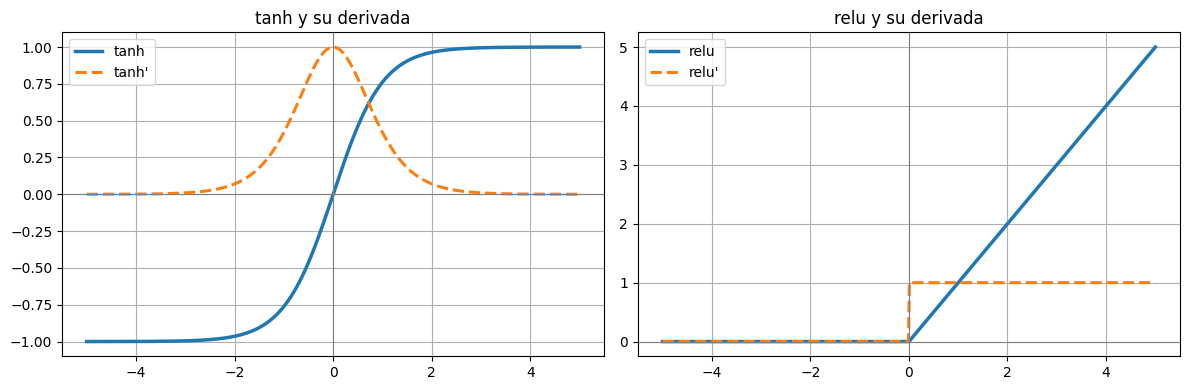

In [ ]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def activation(z, name):
    if name == "relu":
        return np.maximum(0, z)
    if name == "tanh":
        return np.tanh(z)
    raise ValueError("Activación desconocida")

def activation_derivative(z, a, name):
    if name == "relu":
        return (z > 0).astype(float)
    if name == "tanh":
        return 1 - a**2
    raise ValueError("Activación desconocida")

z = np.linspace(-5, 5, 500)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, ["tanh", "relu"]):
    a = activation(z, name)
    ax.plot(z, a, lw=2.5, label=name)
    ax.plot(z, activation_derivative(z, a, name), "--", lw=2.2, label=f"{name}'")
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(f"{name} y su derivada"); ax.legend()
plt.tight_layout(); plt.show()


## 3. Estrategias de inicialización

- **Ceros:** no rompe la simetría; las neuronas de una capa aprenden lo mismo. Con ReLU y sesgos cero, la red puede quedar bloqueada desde la primera iteración.
- **Aleatoria pequeña:** rompe la simetría, pero puede reducir activaciones y gradientes al atravesar muchas capas.
- **Aleatoria grande:** puede producir activaciones o gradientes muy grandes; con `tanh` también provoca saturación.
- **Xavier:** escala recomendada para `tanh`.
- **He:** escala recomendada para ReLU; el factor 2 compensa que aproximadamente la mitad de las activaciones queda en cero.


### ¿Cómo aparecen los gradientes desvanecidos o explosivos?

Durante la retropropagación se multiplican sucesivamente matrices de pesos y derivadas de activación:

$$dA^{[l-1]}=W^{[l]T}dZ^{[l]},$$

$$dZ^{[l]}=dA^{[l]}\odot g'(Z^{[l]}).$$
cada elemento de $dA^{[l]}$ se multiplica por la derivada de la función de activación correspondiente.

---
En una red profunda, productos repetidos con factores muy pequeños reducen el gradiente; factores muy grandes lo amplifican. Además, para `tanh`:

$$\tanh'(Z)=1-\tanh^2(Z),$$

y cuando $|Z|$ es grande, $\tanh'(Z)\approx0$.

---
Xavier y He no garantizan que el problema desaparezca, pero hacen más probable que la red comience en una región numéricamente estable.


In [ ]:
def initialize(layer_dims, method, seed=SEED):
    rng = np.random.default_rng(seed)
    params = {}
    for l in range(1, len(layer_dims)):
        n_out, n_in = layer_dims[l], layer_dims[l - 1]
        shape = (n_out, n_in)
        if method == "zeros":
            first = np.ones(shape)
        elif method == "One":
            first = np.ones(shape)
        elif method == "small_random":
            first = rng.standard_normal(shape) * 0.01
        elif method == "large_random":
            first = rng.standard_normal(shape) * 10
        elif method == "xavier": # Xavier: desviación estándar sqrt(1 / n_in), recomendada para tanh.
            first = rng.standard_normal(shape) * np.sqrt(1 / n_in)
        elif method == "he": # He: desviación estándar sqrt(2 / n_in), recomendada para ReLU.
            first = rng.standard_normal(shape) * np.sqrt(2 / n_in)
        else:
            raise ValueError("Método desconocido")

        params[f"W{l}"] = first
        params[f"b{l}"] = np.zeros((n_out, 1))
    return params

#Imprimir la desviación estándar de W
for method in ["zeros", "One", "small_random", "large_random", "xavier", "he"]:
    p = initialize([2, 16, 8, 4, 1], method)
    print(f"{method:14s} | std(W1)={p['W1'].std():.4f}")
    print(f"{method:14s} | std(W2)={p['W2'].std():.4f}")
    print(f"{method:14s} | std(W3)={p['W3'].std():.4f}")
    print(f"{method:14s} | std(W4)={p['W4'].std():.4f}")
    print("----------------------------------")

zeros          | std(W1)=0.0000
zeros          | std(W2)=0.0000
zeros          | std(W3)=0.0000
zeros          | std(W4)=0.0000
----------------------------------
One            | std(W1)=0.0000
One            | std(W2)=0.0000
One            | std(W3)=0.0000
One            | std(W4)=0.0000
----------------------------------
small_random   | std(W1)=0.0083
small_random   | std(W2)=0.0087
small_random   | std(W3)=0.0097
small_random   | std(W4)=0.0101
----------------------------------
large_random   | std(W1)=8.3105
large_random   | std(W2)=8.6609
large_random   | std(W3)=9.6844
large_random   | std(W4)=10.1187
----------------------------------
xavier         | std(W1)=0.5876
xavier         | std(W2)=0.2165
xavier         | std(W3)=0.3424
xavier         | std(W4)=0.5059
----------------------------------
he             | std(W1)=0.8310
he             | std(W2)=0.3062
he             | std(W3)=0.4842
he             | std(W4)=0.7155
----------------------------------


**Zeros:** Las neuronas activas son 0%. Esto indica un fallo total en la inicialización.


---
**Ones:** Los std(W) son cercanos a 1 para todas las capas. std(Z) y std(A) se mantienen en un rango razonable al inicio, y el porcentaje de neuronas activas es alrededor del 50% (para ReLU). Los ||dW|| son relativamente pequeños.


---
**Small:** std(W) es muy pequeño (alrededor de 0.01). std(Z) y std(A) disminuyen rápidamente a cero o se mantienen muy pequeños a medida que se profundiza en la red (0.011 en capa 1, luego 0.000). Los ||dW|| son extremadamente pequeños (en el orden de 1e-6).


---
**Large:**  std(W) es muy grande (alrededor de 10). std(Z) y std(A) aumentan drásticamente con cada capa (11.337 en capa 1, hasta 3970.915 en capa 3 para Z). Los ||dW|| son extremadamente grandes (en el orden de 1e+03).


---
**Xavier:** std(W) se escala apropiadamente según 1/n_in. std(Z) y std(A) se mantienen en un rango saludable (cercano a 1 o disminuyendo suavemente) a través de las capas. El porcentaje de saturación de tanh es bajo (2.9% en capa 1, 0.0% en otras). Los ||dW|| son razonables y estables (alrededor de 1e-1 a 1e-0).


---
**He:** std(W) se escala apropiadamente según 2/n_in. std(Z) y std(A) se mantienen estables a través de las capas. El porcentaje de neuronas activas para ReLU es cercano al 50% (ideal). Los ||dW|| son razonables y estables (alrededor de 1e-1 a 1e-0).

### Graficar los pesos

In [ ]:
def plot_initialized_weights(layer_dims, method, seed=42):
    """Grafica la distribución de los pesos de cada capa."""

    params = initialize(layer_dims, method, seed)
    L = len(layer_dims) - 1

    fig, axes = plt.subplots(1, L, figsize=(4 * L, 3.5))

    # Para redes con una sola capa
    if L == 1:
        axes = [axes]

    for l, ax in enumerate(axes, start=1):
        W = params[f"W{l}"]
        weights = W.ravel()  # Convierte la matriz en un vector

        if np.all(weights == 0):
            ax.axvline(0, color="royalblue", linewidth=4)
        else:
            ax.hist(
                weights,
                bins=12,
                color="royalblue",
                edgecolor="black",
                alpha=0.75
            )

        ax.axvline(0, color="red", linestyle="--", linewidth=1)
        ax.set_title(
            f"$W^{{[{l}]}}$: {W.shape}\n"
            f"media={W.mean():.3f}, std={W.std():.3f}"
        )
        ax.set_xlabel("Valor del peso")
        ax.set_ylabel("Frecuencia")

    fig.suptitle(
        f"Inicialización: {method}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()





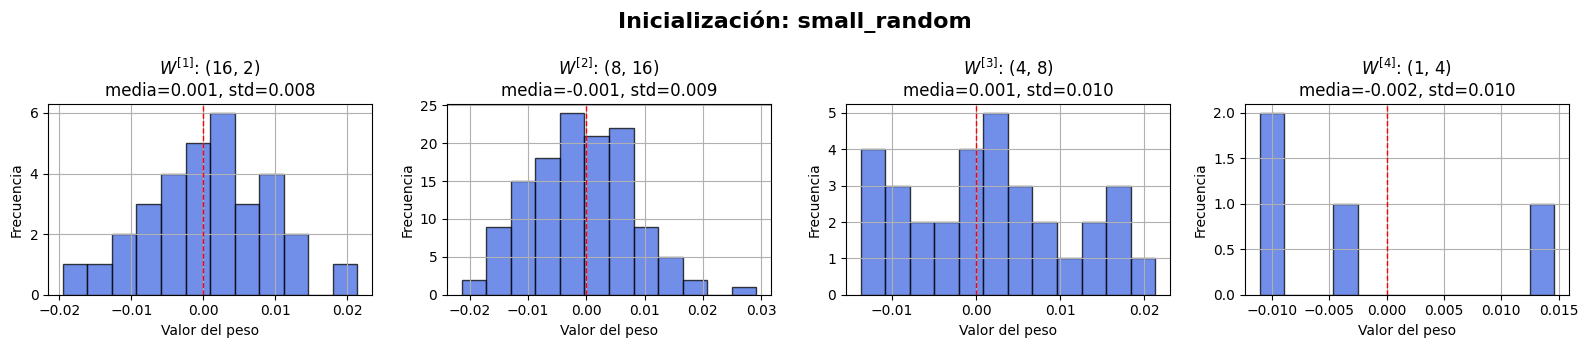

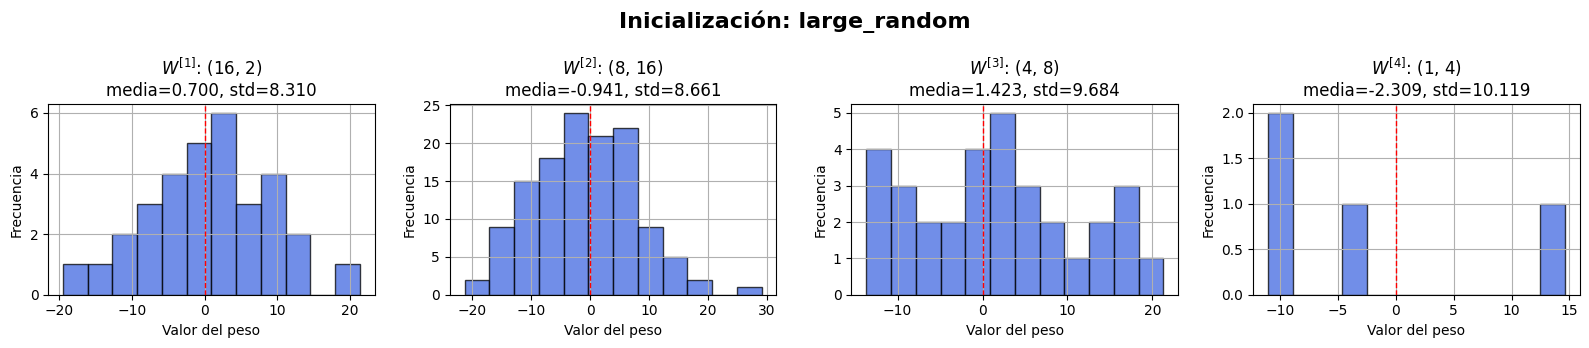

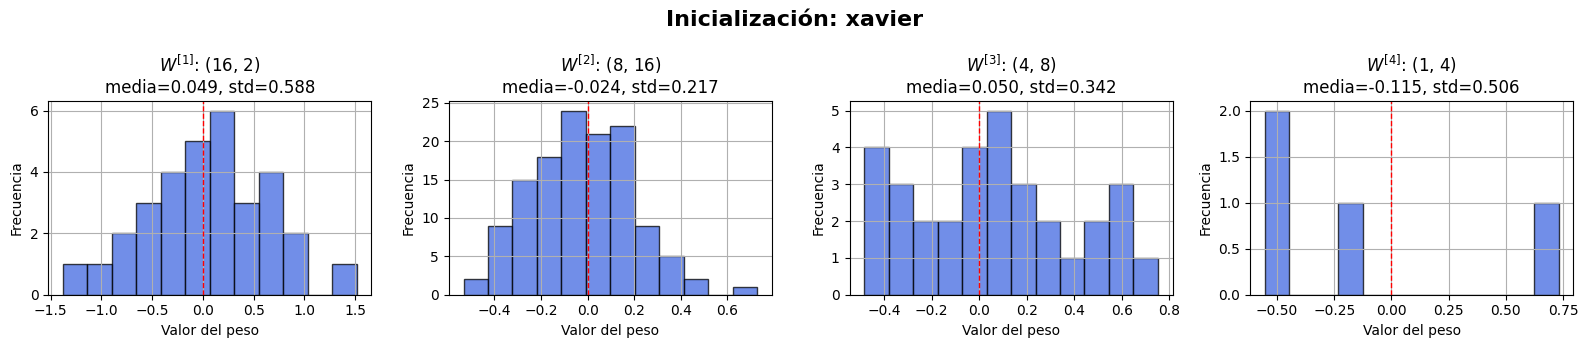

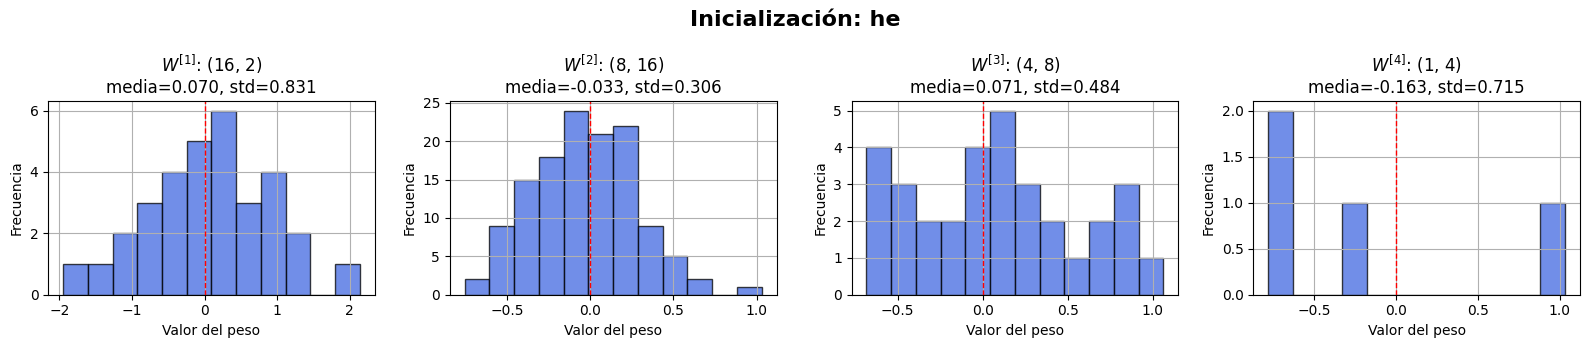

In [ ]:
layer_dims = [2, 16, 8, 4, 1]
for method in [
    "small_random",
    "large_random",
    "xavier",
    "he"
]:
    plot_initialized_weights(layer_dims, method)

In [ ]:
def binary_cross_entropy(AL, Y):
    AL = np.clip(AL, 1e-12, 1 - 1e-12)
    return float(-np.mean(Y * np.log(AL) + (1 - Y) * np.log(1 - AL)))

def forward(X, params, hidden_activation):
    A = X
    caches = []
    L = len(params) // 2
    for l in range(1, L):
        A_prev = A
        W, b = params[f"W{l}"], params[f"b{l}"]
        Z = W @ A_prev + b
        A = activation(Z, hidden_activation)
        caches.append({"A_prev": A_prev, "W": W, "Z": Z, "A": A})
    A_prev = A
    W, b = params[f"W{L}"], params[f"b{L}"]
    Z = W @ A_prev + b
    AL = sigmoid(Z)
    caches.append({"A_prev": A_prev, "W": W, "Z": Z, "A": AL})
    return AL, caches

def backward(AL, Y, caches, hidden_activation):
    grads = {}
    m, L = Y.shape[1], len(caches)
    cache = caches[-1]
    dZ = AL - Y  # Sigmoide + entropía cruzada: dZ^[L] = AL - Y.
    grads[f"dW{L}"] = dZ @ cache["A_prev"].T / m
    grads[f"db{L}"] = np.sum(dZ, axis=1, keepdims=True) / m
    dA = cache["W"].T @ dZ

    for l in reversed(range(1, L)):
        cache = caches[l - 1]
        dZ = dA * activation_derivative(cache["Z"], cache["A"], hidden_activation)
        grads[f"dW{l}"] = dZ @ cache["A_prev"].T / m
        grads[f"db{l}"] = np.sum(dZ, axis=1, keepdims=True) / m
        dA = cache["W"].T @ dZ
    return grads

def update(params, grads, learning_rate):
    L = len(params) // 2
    for l in range(1, L + 1):
        params[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
        params[f"b{l}"] -= learning_rate * grads[f"db{l}"]
    return params

def predict(params, X, hidden_activation):
    return (forward(X, params, hidden_activation)[0] >= 0.5).astype(int)

def accuracy(params, X, Y, hidden_activation):
    return 100 * np.mean(predict(params, X, hidden_activation) == Y)

# Nombres que conectan con la notebook anterior.
L_model_forward = forward
L_model_backward = backward
update_parameters_deep = update
predict_deep = predict


## 4. Diagnóstico antes de entrenar

Antes de actualizar los pesos mediremos:

- la desviación estándar de $Z^{[l]}$ y $A^{[l]}$;
- la fracción saturada de `tanh`, definida aquí como $|Z|>2$;
- la fracción activa de ReLU, $Z>0$;
- la norma de los gradientes $\|dW^{[l]}\|_F$.

Esto conecta directamente la inicialización con el flujo de información hacia adelante y hacia atrás.


In [ ]:
def initialization_diagnostics(method, hidden_activation):
    params = initialize([2, 16, 8, 4, 1], method)
    AL, caches = L_model_forward(X_train, params, hidden_activation)
    grads = L_model_backward(AL, Y_train, caches, hidden_activation)
    print(f"\n{method.upper()} + {hidden_activation}")
    for l, cache in enumerate(caches[:-1], start=1):
        Z, A = cache["Z"], cache["A"]

        extra = (f"saturación={100*np.mean(np.abs(Z)>2):5.1f}%" if hidden_activation == "tanh"
                 else f"activas={100*np.mean(Z>0):5.1f}%")
        print(f"capa {l}: std(Z)={Z.std():7.3f}, std(A)={A.std():7.3f}, "
              f"{extra}, ||dW||={np.linalg.norm(grads[f'dW{l}']):9.3e}")

for method, act in [
    ("zeros", "relu"), ("small_random", "relu"), ("large_random", "relu"),
    ("xavier", "tanh"), ("he", "relu")
]:
    initialization_diagnostics(method, act)



ZEROS + relu
capa 1: std(Z)=  1.145, std(A)=  0.659, activas= 49.6%, ||dW||=3.729e+01
capa 2: std(Z)= 10.543, std(A)= 10.543, activas= 49.6%, ||dW||=1.207e+01
capa 3: std(Z)= 84.347, std(A)= 84.347, activas= 49.6%, ||dW||=2.415e+01

SMALL_RANDOM + relu
capa 1: std(Z)=  0.011, std(A)=  0.007, activas= 50.1%, ||dW||=1.701e-06
capa 2: std(Z)=  0.000, std(A)=  0.000, activas= 30.9%, ||dW||=1.645e-06
capa 3: std(Z)=  0.000, std(A)=  0.000, activas= 53.6%, ||dW||=1.035e-06

LARGE_RANDOM + relu
capa 1: std(Z)= 11.337, std(A)=  6.762, activas= 50.1%, ||dW||=3.292e+03
capa 2: std(Z)=222.489, std(A)=110.748, activas= 30.9%, ||dW||=3.575e+03
capa 3: std(Z)=3970.915, std(A)=3251.035, activas= 53.6%, ||dW||=2.301e+03

XAVIER + tanh
capa 1: std(Z)=  0.802, std(A)=  0.532, saturación=  2.9%, ||dW||=2.136e-01
capa 2: std(Z)=  0.432, std(A)=  0.372, saturación=  0.0%, ||dW||=4.689e-01
capa 3: std(Z)=  0.285, std(A)=  0.259, saturación=  0.0%, ||dW||=3.642e-01

HE + relu
capa 1: std(Z)=  1.134, std(A)=

#### Comparación en forma gráfica

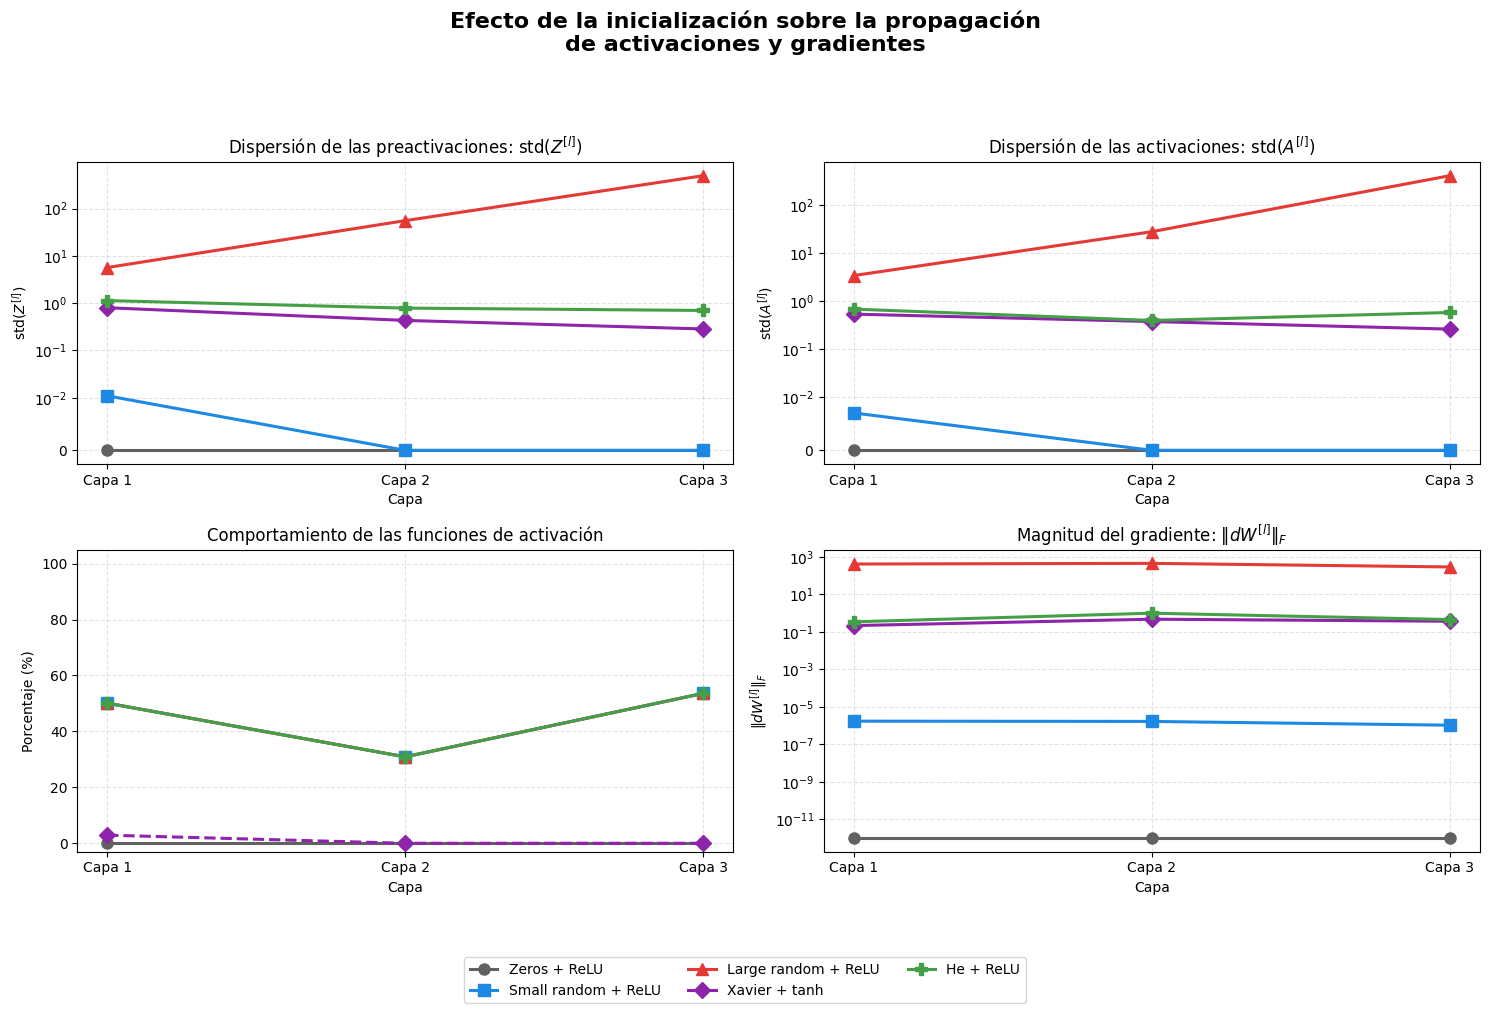

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Resultados obtenidos para cada método de inicialización
# ============================================================

resultados = {
    "Zeros + ReLU": {
        "std_Z": [0.000, 0.000, 0.000],
        "std_A": [0.000, 0.000, 0.000],
        "porcentaje": [0.0, 0.0, 0.0],
        "tipo_porcentaje": "Neuronas activas",
        "grad_W": [0.000e+00, 0.000e+00, 0.000e+00]
    },

    "Small random + ReLU": {
        "std_Z": [0.011, 0.000, 0.000],
        "std_A": [0.007, 0.000, 0.000],
        "porcentaje": [50.1, 30.9, 53.6],
        "tipo_porcentaje": "Neuronas activas",
        "grad_W": [1.701e-06, 1.645e-06, 1.035e-06]
    },

    "Large random + ReLU": {
        "std_Z": [5.669, 55.622, 496.364],
        "std_A": [3.381, 27.687, 406.379],
        "porcentaje": [50.1, 30.9, 53.6],
        "tipo_porcentaje": "Neuronas activas",
        "grad_W": [4.115e+02, 4.469e+02, 2.876e+02]
    },

    "Xavier + tanh": {
        "std_Z": [0.802, 0.432, 0.285],
        "std_A": [0.532, 0.372, 0.259],
        "porcentaje": [2.9, 0.0, 0.0],
        "tipo_porcentaje": "Saturación",
        "grad_W": [2.136e-01, 4.689e-01, 3.642e-01]
    },

    "He + ReLU": {
        "std_Z": [1.134, 0.787, 0.702],
        "std_A": [0.676, 0.392, 0.575],
        "porcentaje": [50.1, 30.9, 53.6],
        "tipo_porcentaje": "Neuronas activas",
        "grad_W": [3.397e-01, 9.806e-01, 4.490e-01]
    }
}

capas = np.arange(1, 4)

colores = {
    "Zeros + ReLU": "#616161",
    "Small random + ReLU": "#1E88E5",
    "Large random + ReLU": "#E53935",
    "Xavier + tanh": "#8E24AA",
    "He + ReLU": "#43A047"
}

marcadores = ["o", "s", "^", "D", "P"]

# ============================================================
# Creación de las gráficas
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for (nombre, datos), marcador in zip(resultados.items(), marcadores):

    color = colores[nombre]

    # Desviación estándar de Z
    axes[0, 0].plot(
        capas,
        datos["std_Z"],
        marker=marcador,
        linewidth=2.2,
        markersize=8,
        color=color,
        label=nombre
    )

    # Desviación estándar de A
    axes[0, 1].plot(
        capas,
        datos["std_A"],
        marker=marcador,
        linewidth=2.2,
        markersize=8,
        color=color,
        label=nombre
    )

    # Porcentaje de activación o saturación
    estilo = "--" if datos["tipo_porcentaje"] == "Saturación" else "-"

    axes[1, 0].plot(
        capas,
        datos["porcentaje"],
        marker=marcador,
        linewidth=2.2,
        markersize=8,
        linestyle=estilo,
        color=color,
        label=f"{nombre} ({datos['tipo_porcentaje']})"
    )

    # Norma del gradiente
    # Los ceros se sustituyen únicamente para poder mostrarlos
    # en la escala logarítmica.
    gradiente_grafica = np.maximum(datos["grad_W"], 1e-12)

    axes[1, 1].plot(
        capas,
        gradiente_grafica,
        marker=marcador,
        linewidth=2.2,
        markersize=8,
        color=color,
        label=nombre
    )

# ============================================================
# Configuración de cada gráfica
# ============================================================

axes[0, 0].set_title(
    r"Dispersión de las preactivaciones: $\mathrm{std}(Z^{[l]})$"
)
axes[0, 0].set_ylabel(r"$\mathrm{std}(Z^{[l]})$")
axes[0, 0].set_yscale("symlog", linthresh=0.01)

axes[0, 1].set_title(
    r"Dispersión de las activaciones: $\mathrm{std}(A^{[l]})$"
)
axes[0, 1].set_ylabel(r"$\mathrm{std}(A^{[l]})$")
axes[0, 1].set_yscale("symlog", linthresh=0.01)

axes[1, 0].set_title("Comportamiento de las funciones de activación")
axes[1, 0].set_ylabel("Porcentaje (%)")
axes[1, 0].set_ylim(-3, 105)

axes[1, 1].set_title(
    r"Magnitud del gradiente: $\Vert dW^{[l]}\Vert_F$"
)
axes[1, 1].set_ylabel(r"$\Vert dW^{[l]}\Vert_F$")
axes[1, 1].set_yscale("log")

for ax in axes.flat:
    ax.set_xlabel("Capa")
    ax.set_xticks(capas)
    ax.set_xticklabels([f"Capa {l}" for l in capas])
    ax.grid(True, linestyle="--", alpha=0.35)

# Una sola leyenda para evitar repeticiones
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=True
)

fig.suptitle(
    "Efecto de la inicialización sobre la propagación\n"
    "de activaciones y gradientes",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()

## 5. Entrenamiento controlado

Compararemos primero los fallos típicos usando ReLU. Después mostraremos las dos parejas recomendadas:

$$\text{Xavier + tanh},\qquad \text{He + ReLU}.$$

La capa de salida utiliza sigmoide y entropía cruzada, por lo que:

$$dZ^{[L]}=A^{[L]}-Y.$$


Ceros + ReLU       train= 76.44%  test= 81.33%
Pequeña + ReLU     train= 83.33%  test= 82.00%
Grande + ReLU      train= 50.00%  test= 50.00%
Xavier + tanh      train= 94.89%  test= 94.00%
He + ReLU          train= 95.11%  test= 94.67%


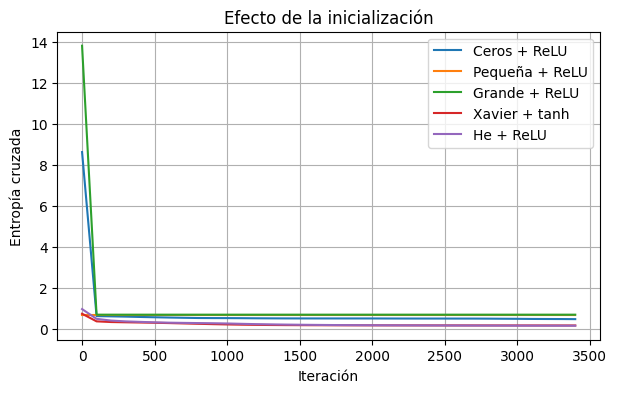

In [ ]:
def train_initialization(method, hidden_activation, iterations=3500, learning_rate=0.03):
    params = initialize([2, 16, 8, 4, 1], method)
    history = []
    for i in range(iterations):
        AL, caches = L_model_forward(X_train, params, hidden_activation)
        grads = L_model_backward(AL, Y_train, caches, hidden_activation)
        params = update_parameters_deep(params, grads, learning_rate)
        if i % 100 == 0:
            history.append(binary_cross_entropy(AL, Y_train))
    return params, history

experiments = {
    "Ceros + ReLU": ("zeros", "relu"),

    "Pequeña + ReLU": ("small_random", "relu"),
    "Grande + ReLU": ("large_random", "relu"),
    "Xavier + tanh": ("xavier", "tanh"),
    "He + ReLU": ("he", "relu"),
}

models, histories = {}, {}
for name, (method, act) in experiments.items():
    models[name], histories[name] = train_initialization(method, act)
    print(f"{name:18s} train={accuracy(models[name], X_train, Y_train, act):6.2f}%  "
          f"test={accuracy(models[name], X_test, Y_test, act):6.2f}%")

for name, values in histories.items():
    plt.plot(np.arange(len(values)) * 100, values, label=name)
plt.xlabel("Iteración"); plt.ylabel("Entropía cruzada")
plt.title("Efecto de la inicialización"); plt.legend(); plt.show()


### Lectura esperada de los resultados

No debemos juzgar la inicialización solamente por la exactitud final. También observaremos:

- **Ceros:** gradientes ocultos iguales o nulos; no se rompe la simetría.
- **Pesos pequeños:** activaciones y gradientes disminuyen con la profundidad.
- **Pesos grandes:** activaciones y gradientes aumentan con la profundidad.
- **Xavier/He:** las escalas permanecen más cercanas entre capas y el costo suele descender con mayor estabilidad.

La comparación Xavier–He no pretende demostrar que una sea universalmente mejor: cada una está asociada con una activación diferente.


##Graficar fronteras de cada experimento

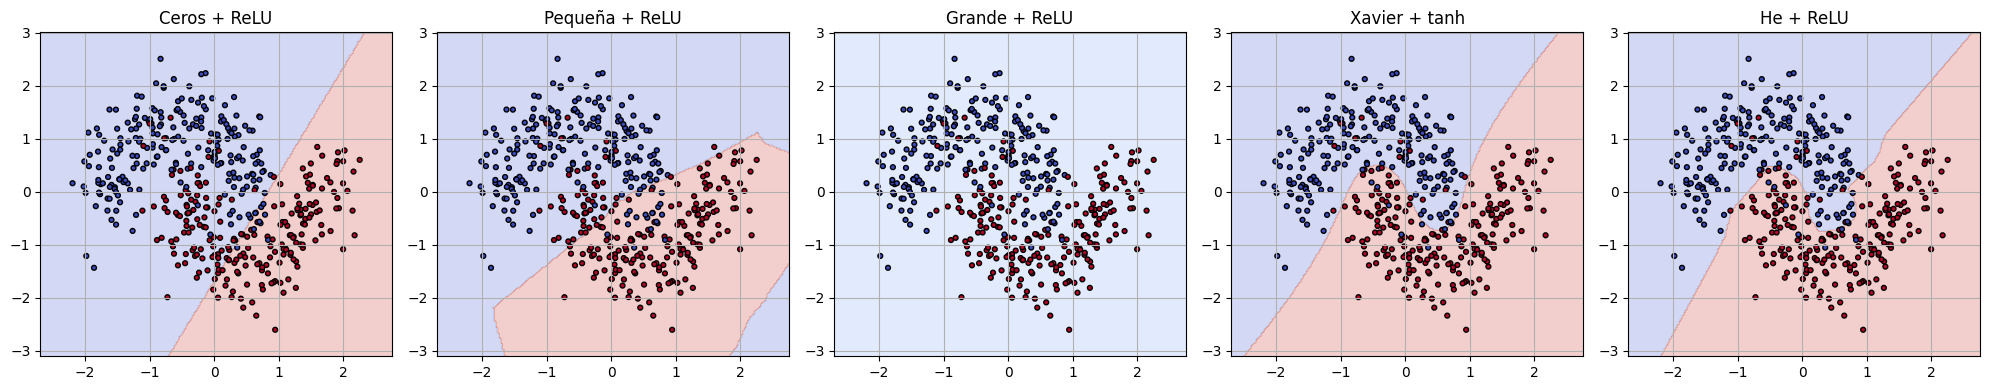

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
x1 = np.linspace(X_train[0].min() - 0.5, X_train[0].max() + 0.5, 220)
x2 = np.linspace(X_train[1].min() - 0.5, X_train[1].max() + 0.5, 220)
xx, yy = np.meshgrid(x1, x2)
grid = np.vstack([xx.ravel(), yy.ravel()])

for ax, (name, params) in zip(axes, models.items()):
    act = experiments[name][1]
    zz = predict(params, grid, act).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_train[0], X_train[1], c=Y_train.ravel(), cmap="coolwarm",
               edgecolor="k", s=12)
    ax.set_title(name)
plt.tight_layout(); plt.show()


##RESULTADOS FINALES

In [ ]:
print("RESULTADOS FINALES")
print("-" * 52)

for name, params in models.items():
    activation_name = experiments[name][1]

    train_acc = accuracy(
        params, X_train, Y_train, activation_name
    )

    test_acc = accuracy(
        params, X_test, Y_test, activation_name
    )

    print(
        f"{name:18s} | "
        f"Train: {train_acc:6.2f}% | "
        f"Test: {test_acc:6.2f}%"
    )

RESULTADOS FINALES
----------------------------------------------------
Ceros + ReLU       | Train:  76.44% | Test:  81.33%
Pequeña + ReLU     | Train:  83.33% | Test:  82.00%
Grande + ReLU      | Train:  50.00% | Test:  50.00%
Xavier + tanh      | Train:  94.89% | Test:  94.00%
He + ReLU          | Train:  95.11% | Test:  94.67%


## 6. Conclusiones y preguntas breves

###**Escribe tus propias conclusiones**


-----
### **Preguntas breves**

###1. ¿Por qué los sesgos pueden comenzar en cero y los pesos ocultos no?
porque con ello ya no se tomaria en cuenta las caracteristicas ni tomariamos los valores de esta porque se iria a 0.

---


###2. ¿Qué medidas muestran que una inicialización está produciendo saturación o explosión?

1. **Desviación Estandar de las preactivaciones:** dependiendo de su valor nos indicara si estas se desvanecen o explotan
2. **Desviación estándar de las activaciones:** en la región de saturación donde la derivada es casi cero
---

###3. ¿La iniciación Xavier o He garantizan la convergencia?
No, no logran converger en algo pero si logran alcanzar una solución muy buena.
La principal función de Xavier y He es mantener las activaciones y los gradientes de las capas intermedias dentro de un rango razonable al inicio del entrenamiento

---

###4. ¿La inicialización cambia la capacidad de la arquitectura o principalmente facilita su optimización?

**No** cambia la capacidad de la arquitectura porque al final porque al final siempre una red aprendera a responder de manera correcta pero el numero de ciclos para lograr esto si será importante de la inicialización

